<a href="https://colab.research.google.com/github/HanaaMaswada/RTT-Correlation-with-Transfer-phases-of-a-file-download/blob/main/an_empirical_measurement_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Upload the Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving phase1_results (1).csv to phase1_results (1).csv


Step 2 — Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 3 — Read the CSV File

In [ ]:
df = pd.read_csv("phase1_results (1).csv")

Step 4 — Display the First Rows

In [ ]:
df.head()

,timestamp_utc,server_name,url,trial,host,resolved_ip,ping_sent,ping_received,ping_loss_pct,rtt_min_ms,...,error_message,python_version,curl_version,platform,ip_city,ip_region,ip_country,ip_org,ip_timezone,ip_loc
0,2026-05-10T10:04:40+00:00,Hetzner-DE,https://nbg1-speed.hetzner.com/100MB.bin,1,nbg1-speed.hetzner.com,88.198.248.254,10,10,0,66.0,...,NaN,3.13.0,curl 8.18.0 (Windows) libcurl/8.18.0 Schannel ...,Windows-11-10.0.26200-SP0,Falkenstein,Saxony,DE,AS24940 Hetzner Online GmbH,Europe/Berlin,"50.4779,12.3713"
1,2026-05-10T10:04:50+00:00,Hetzner-DE,https://nbg1-speed.hetzner.com/100MB.bin,2,nbg1-speed.hetzner.com,88.198.248.254,10,10,0,66.0,...,NaN,3.13.0,curl 8.18.0 (Windows) libcurl/8.18.0 Schannel ...,Windows-11-10.0.26200-SP0,Falkenstein,Saxony,DE,AS24940 Hetzner Online GmbH,Europe/Berlin,"50.4779,12.3713"
2,2026-05-10T10:05:00+00:00,Hetzner-DE,https://nbg1-speed.hetzner.com/100MB.bin,3,nbg1-speed.hetzner.com,88.198.248.254,10,10,0,66.0,...,NaN,3.13.0,curl 8.18.0 (Windows) libcurl/8.18.0 Schannel ...,Windows-11-10.0.26200-SP0,Falkenstein,Saxony,DE,AS24940 Hetzner Online GmbH,Europe/Berlin,"50.4779,12.3713"
3,2026-05-10T10:05:21+00:00,Hetzner-ASH,https://ash-speed.hetzner.com/100MB.bin,1,ash-speed.hetzner.com,5.161.7.195,10,10,0,141.0,...,NaN,3.13.0,curl 8.18.0 (Windows) libcurl/8.18.0 Schannel ...,Windows-11-10.0.26200-SP0,Ashburn,Virginia,US,AS213230 Hetzner Online GmbH,America/New_York,"39.0437,-77.4875"
4,2026-05-10T10:05:32+00:00,Hetzner-ASH,https://ash-speed.hetzner.com/100MB.bin,2,ash-speed.hetzner.com,5.161.7.195,10,10,0,141.0,...,NaN,3.13.0,curl 8.18.0 (Windows) libcurl/8.18.0 Schannel ...,Windows-11-10.0.26200-SP0,Ashburn,Virginia,US,AS213230 Hetzner Online GmbH,America/New_York,"39.0437,-77.4875"


Step 5 — Check Dataset Shape

In [ ]:
df.shape

(978, 34)

Step 6 — Display Column Names

In [ ]:
df.columns

Index(['timestamp_utc', 'server_name', 'url', 'trial', 'host', 'resolved_ip',
       'ping_sent', 'ping_received', 'ping_loss_pct', 'rtt_min_ms',
       'rtt_avg_ms', 'rtt_max_ms', 'dns_time_s', 'tcp_connect_time_s',
       'tls_handshake_time_s', 'ttfb_s', 'total_time_s', 'download_speed_Bps',
       'throughput_Mbps', 'http_code', 'remote_ip', 'size_download_bytes',
       'ping_status', 'curl_status', 'error_message', 'python_version',
       'curl_version', 'platform', 'ip_city', 'ip_region', 'ip_country',
       'ip_org', 'ip_timezone', 'ip_loc'],
      dtype='object')

Step 7 — Display Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 978 entries, 0 to 977
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp_utc         978 non-null    object 
 1   server_name           978 non-null    object 
 2   url                   978 non-null    object 
 3   trial                 978 non-null    int64  
 4   host                  978 non-null    object 
 5   resolved_ip           978 non-null    object 
 6   ping_sent             978 non-null    int64  
 7   ping_received         978 non-null    int64  
 8   ping_loss_pct         978 non-null    int64  
 9   rtt_min_ms            969 non-null    float64
 10  rtt_avg_ms            969 non-null    float64
 11  rtt_max_ms            969 non-null    float64
 12  dns_time_s            978 non-null    float64
 13  tcp_connect_time_s    978 non-null    float64
 14  tls_handshake_time_s  978 non-null    float64
 15  ttfb_s                9

Step 8 — Keep Only Successful Downloads

In [ ]:
df = df[df["curl_status"] == "ok"]

Step 9 — Keep Only Successful Ping Measurements

In [ ]:
df = df[df["ping_status"] == "ok"]

Step 10 — Keep Only 100MB Downloads

In [ ]:
df = df[df["size_download_bytes"] == 104857600]

Step 11 — Check Dataset After Cleaning

In [ ]:
df.shape

(402, 34)

Step 12 — Select Important Columns

In [ ]:
important_cols = [
    "server_name",
    "rtt_avg_ms",
    "dns_time_s",
    "tcp_connect_time_s",
    "tls_handshake_time_s",
    "ttfb_s",
    "throughput_Mbps",
    "total_time_s"
]

df = df[important_cols]

Step 13 — Display Cleaned Dataset

In [ ]:
df.head()

,server_name,rtt_avg_ms,dns_time_s,tcp_connect_time_s,tls_handshake_time_s,ttfb_s,throughput_Mbps,total_time_s
0,Hetzner-DE,66.0,0.008766,0.077890,0.241945,0.377981,73.958976,11.342244
1,Hetzner-DE,66.0,0.007465,0.088902,0.242910,0.384327,86.450552,9.703359
2,Hetzner-DE,66.0,0.006877,0.078690,0.244855,0.387631,86.368816,9.712542
3,Hetzner-ASH,141.0,0.008758,0.154337,0.309441,0.598677,72.013944,11.648588
4,Hetzner-ASH,141.0,0.007878,0.150208,0.302898,0.581904,79.701528,10.525027


Step 14 — Descriptive Statistics

In [ ]:
df.describe()

,rtt_avg_ms,dns_time_s,tcp_connect_time_s,tls_handshake_time_s,ttfb_s,throughput_Mbps,total_time_s
count,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000
mean,78.726368,0.008109,0.092071,0.178808,0.341000,73.767158,12.730046
std,30.152642,0.002671,0.030325,0.132330,0.173750,17.051416,7.800811
min,59.000000,0.005810,0.064425,0.000000,0.124415,7.293072,9.306930
25%,63.000000,0.006543,0.072109,0.140873,0.264247,64.893434,9.547572
50%,65.000000,0.007334,0.076864,0.162434,0.290160,79.055104,10.611089
75%,68.000000,0.009028,0.094312,0.248790,0.390268,87.861178,12.926743
max,154.000000,0.035014,0.175928,0.689484,0.824349,90.132920,115.021477


Step 15 — Set Visualization Style

In [ ]:
sns.set(style="whitegrid")

Step 16 — Plot RTT Distribution

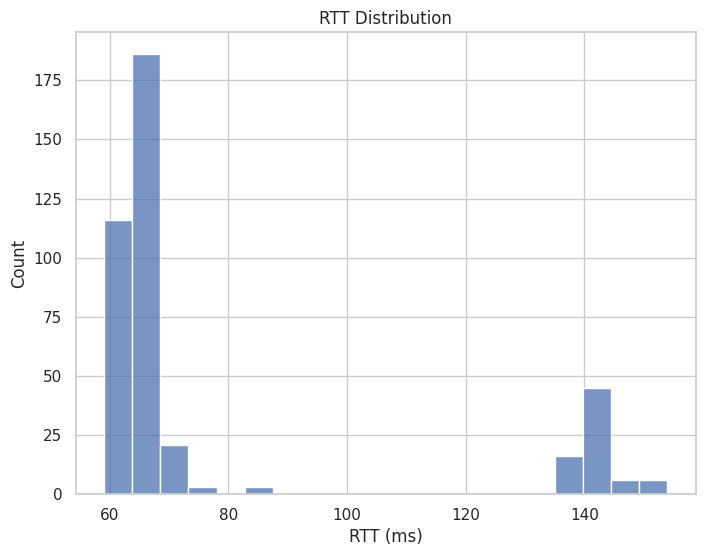

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(df["rtt_avg_ms"], bins=20)

plt.title("RTT Distribution")
plt.xlabel("RTT (ms)")
plt.ylabel("Count")
sns.histplot(kde=True)

plt.show()

Step 17 — Plot RTT vs TTFB

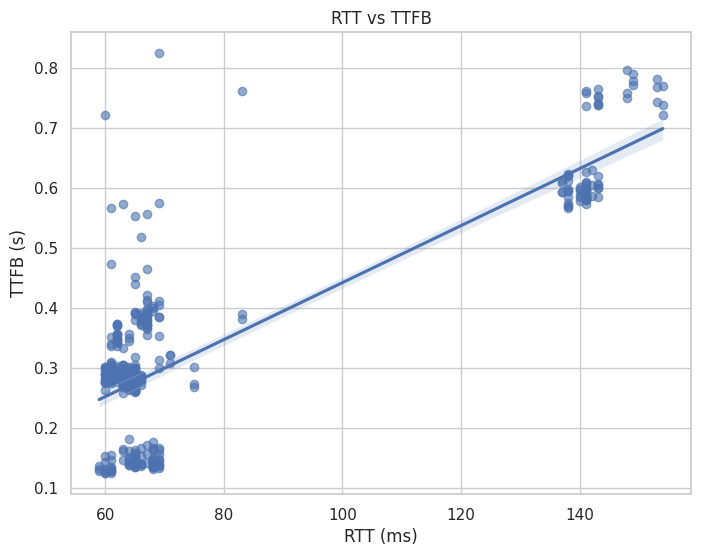

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="rtt_avg_ms",
    y="ttfb_s",
    scatter_kws={"alpha":0.6}
)

plt.title("RTT vs TTFB")
plt.xlabel("RTT (ms)")
plt.ylabel("TTFB (s)")

plt.show()

Step 18 — Plot RTT vs Throughput

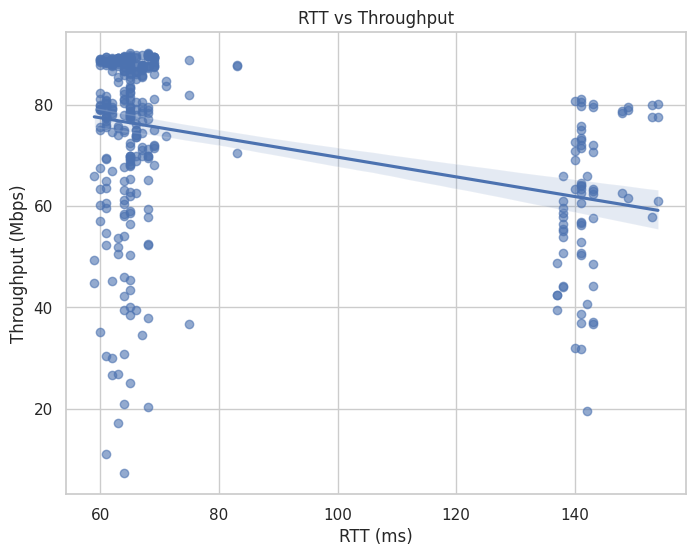

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="rtt_avg_ms",
    y="throughput_Mbps",
    scatter_kws={"alpha":0.6}
)

plt.title("RTT vs Throughput")
plt.xlabel("RTT (ms)")
plt.ylabel("Throughput (Mbps)")

plt.show()

Step 19 — Plot RTT vs TCP Connection Time

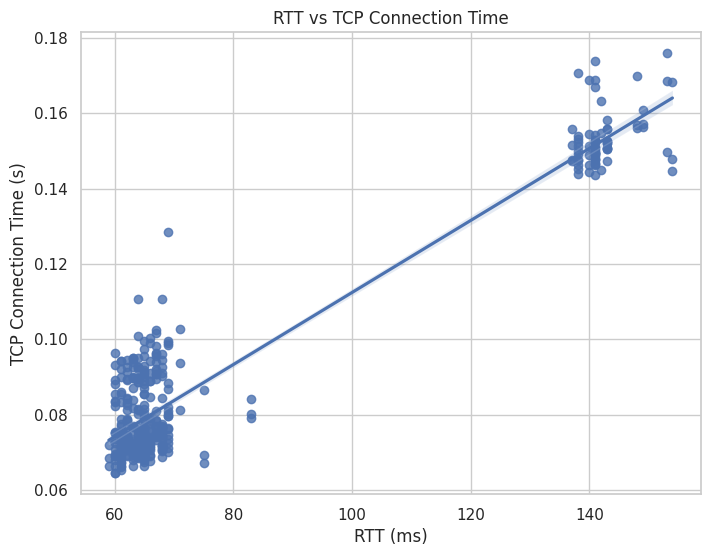

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="rtt_avg_ms",
    y="tcp_connect_time_s"
)

plt.title("RTT vs TCP Connection Time")
plt.xlabel("RTT (ms)")
plt.ylabel("TCP Connection Time (s)")

plt.show()

Step 20 — Plot Throughput Distribution per Server

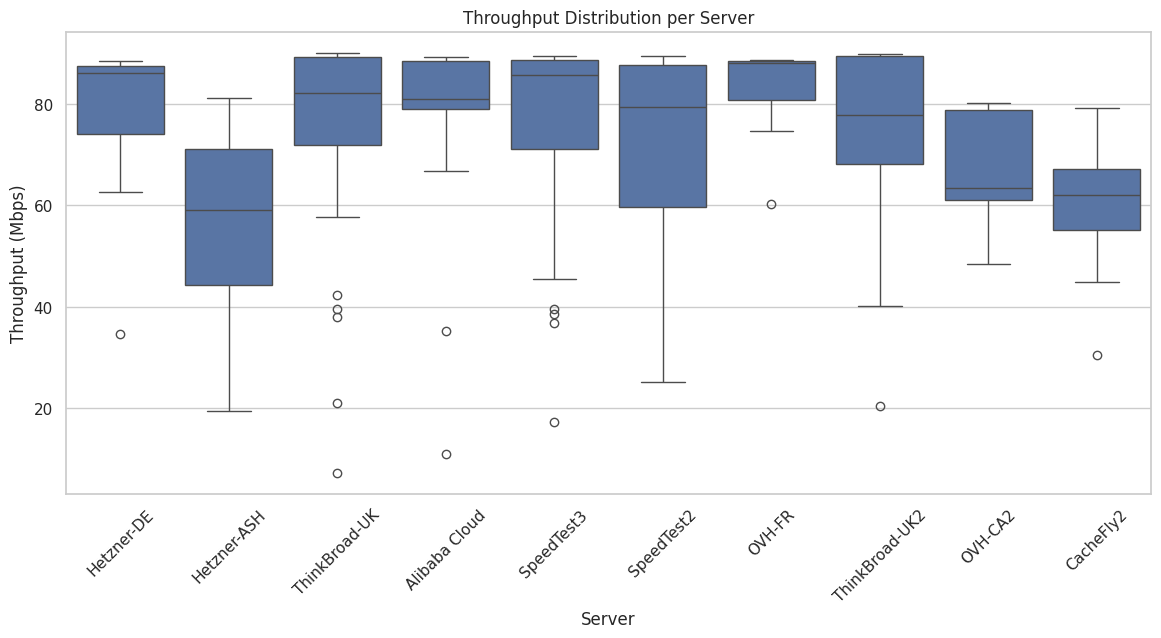

In [ ]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="server_name",
    y="throughput_Mbps"
)

plt.xticks(rotation=45)

plt.title("Throughput Distribution per Server")
plt.xlabel("Server")
plt.ylabel("Throughput (Mbps)")

plt.show()

Step 21 — Plot Correlation Heatmap

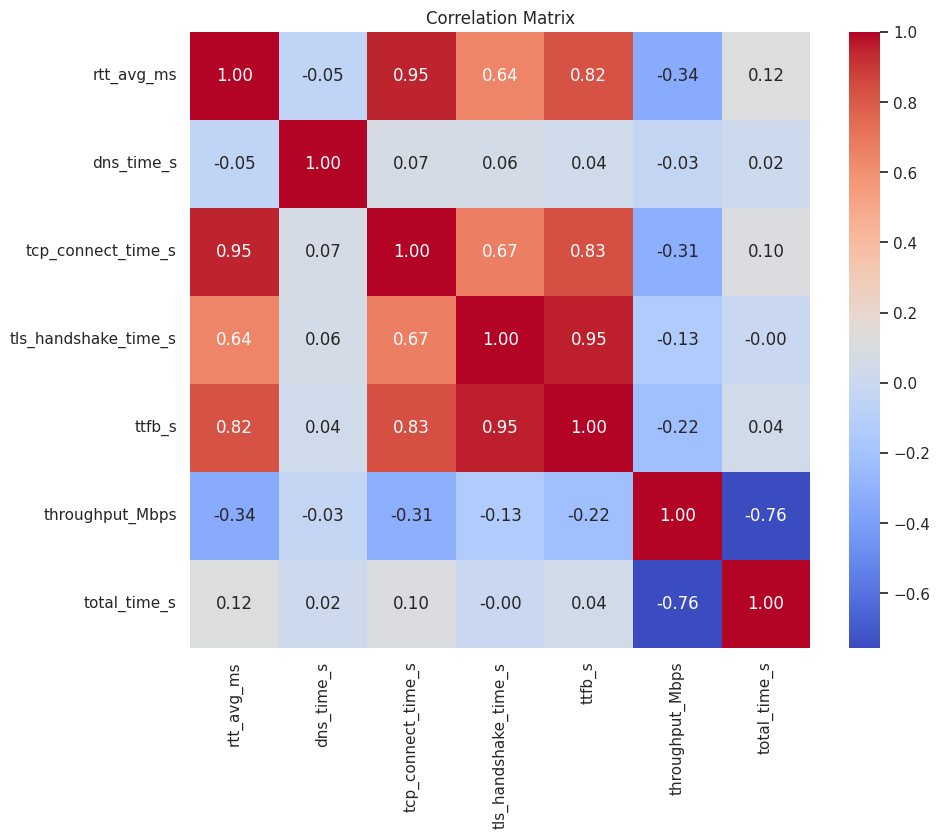

In [ ]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Step 22 — Import Pearson Correlation Function

In [ ]:
from scipy.stats import pearsonr

Step 23 — Calculate Pearson Correlation Between RTT and TTFB

In [ ]:
pearsonr(df["rtt_avg_ms"], df["ttfb_s"])

PearsonRResult(statistic=np.float64(0.8247151764831364), pvalue=np.float64(4.695783426387161e-101))

Step 24 — Calculate Pearson Correlation Between RTT and Throughput

In [ ]:
pearsonr(df["rtt_avg_ms"], df["throughput_Mbps"])

PearsonRResult(statistic=np.float64(-0.34345085089769545), pvalue=np.float64(1.4283815388070202e-12))

Step 25 — Calculate Pearson Correlation Between RTT and TCP Connection Time

In [ ]:
pearsonr(df["rtt_avg_ms"], df["tcp_connect_time_s"])

PearsonRResult(statistic=np.float64(0.9508422353355734), pvalue=np.float64(9.666533434476337e-206))

##Pairplot

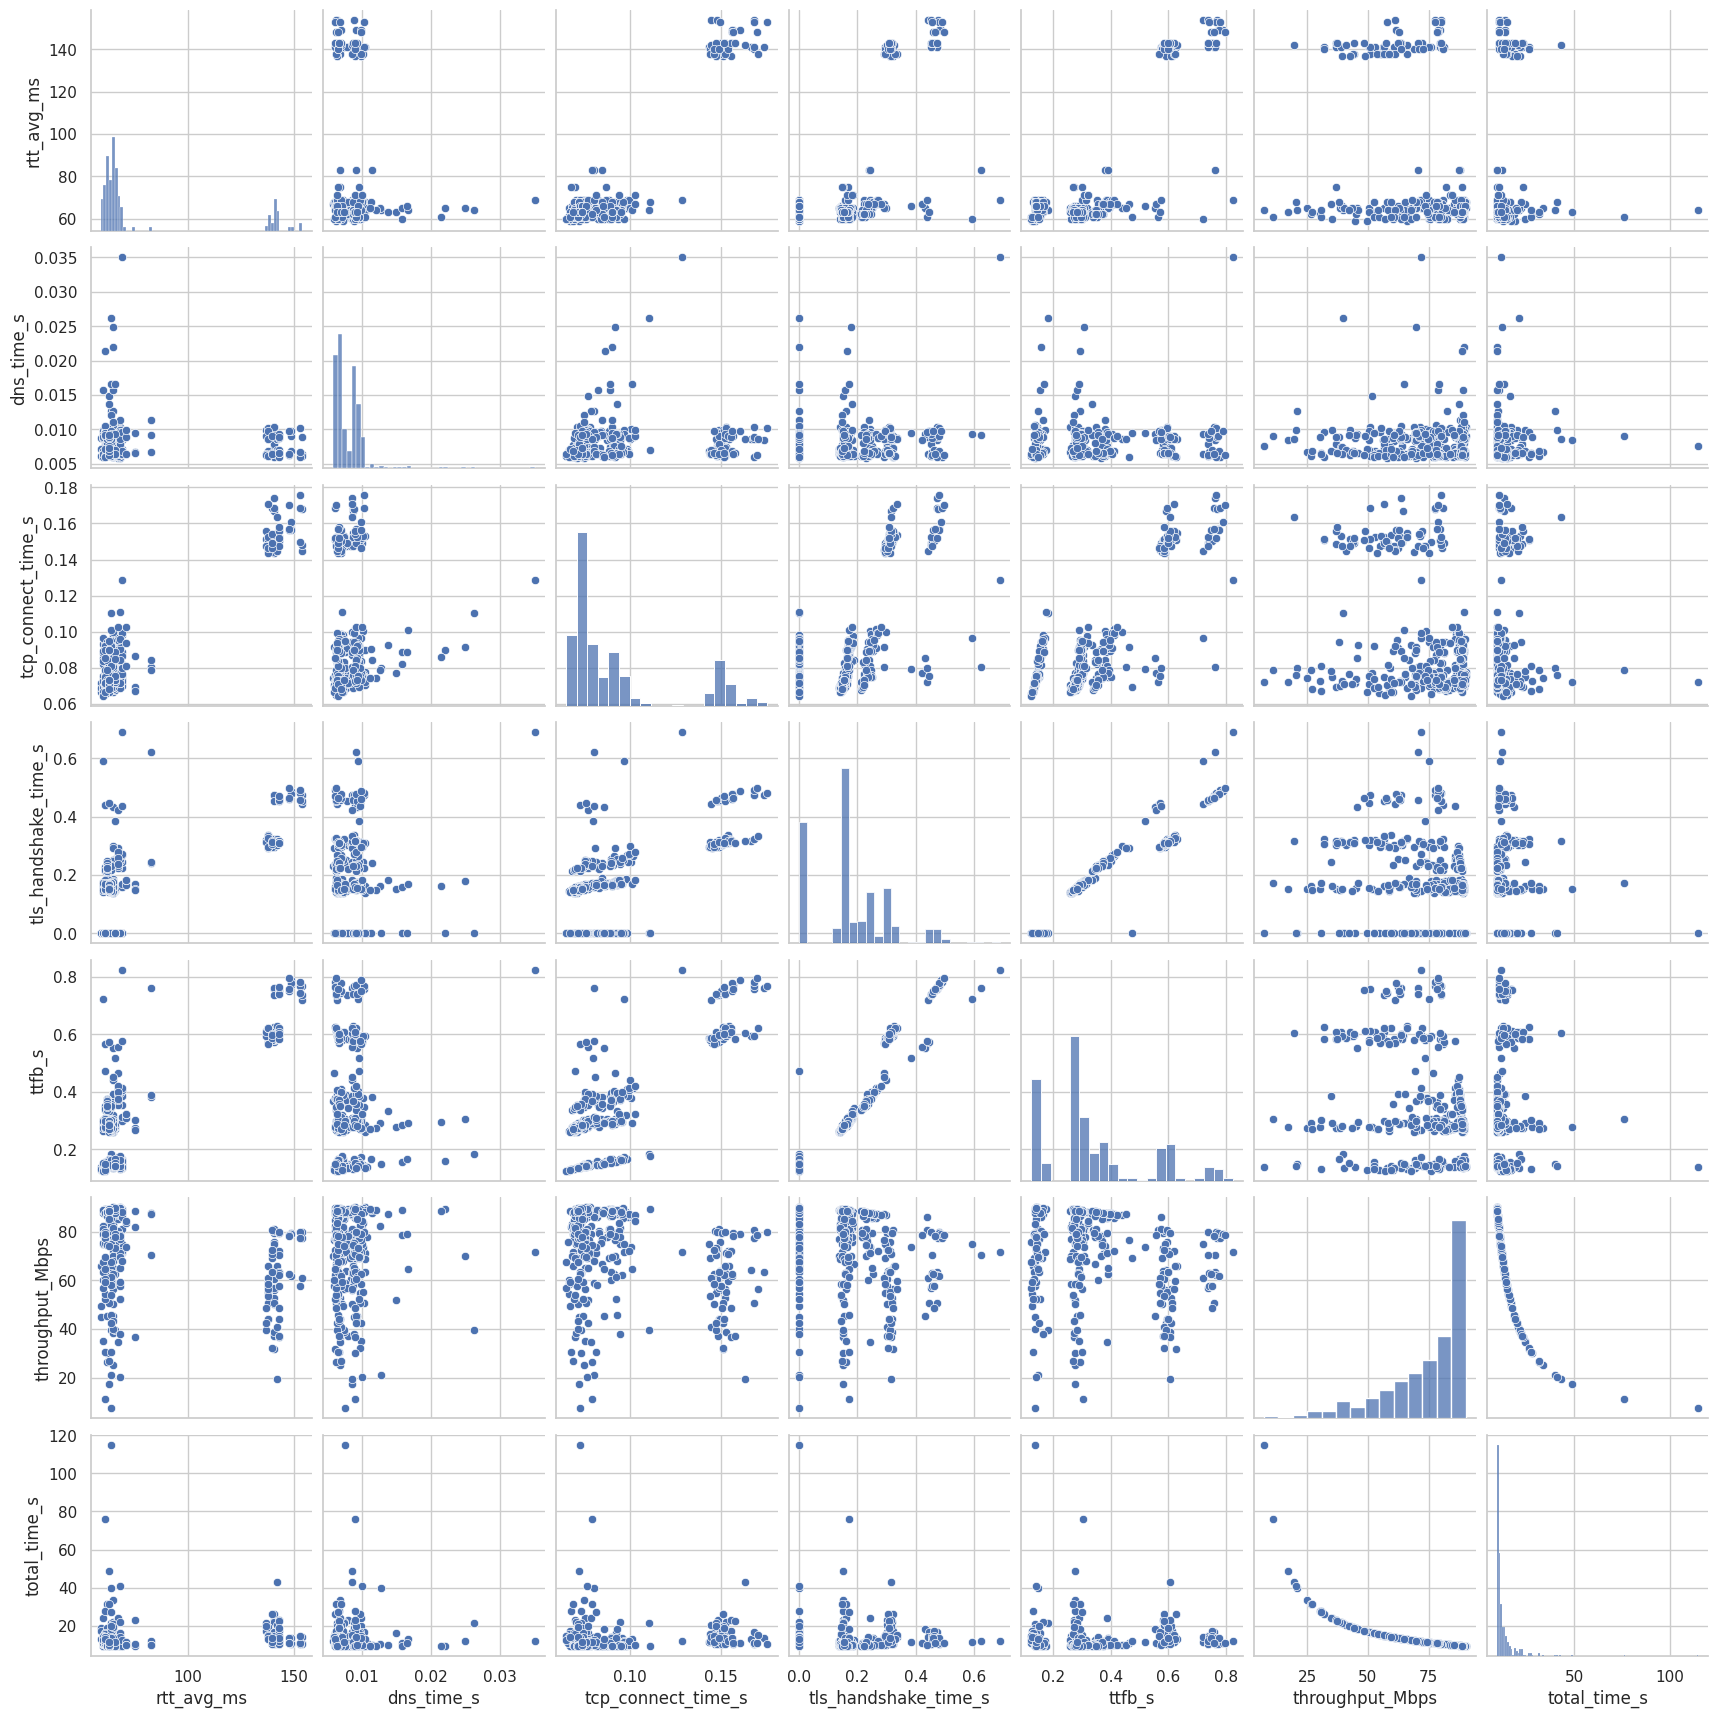

In [ ]:
sns.pairplot(df)

Step 26 — Create Server Delay Column

In [ ]:
df["server_delay_s"] = (
    df["ttfb_s"]
    - df["dns_time_s"]
    - df["tcp_connect_time_s"]
    - df["tls_handshake_time_s"]
)

Step 27 — Calculate Average Phase Times per Server

In [ ]:
phase_avg = df.groupby("server_name")[[
    "dns_time_s",
    "tcp_connect_time_s",
    "tls_handshake_time_s",
    "server_delay_s"
]].mean()

Step 28 — Display Phase Breakdown Table

In [ ]:
phase_avg.head()

,dns_time_s,tcp_connect_time_s,tls_handshake_time_s,server_delay_s
server_name,,,,
Alibaba Cloud,0.008260,0.077631,0.175518,0.042529
CacheFly2,0.007570,0.072178,0.000000,0.073180
Hetzner-ASH,0.007835,0.151350,0.310868,0.125047
Hetzner-DE,0.008299,0.086039,0.266706,0.045956
OVH-CA2,0.007758,0.157612,0.468590,0.123397


Step 29 — Plot Phase Breakdown Chart

In [ ]:
server_rtt = df.groupby("server_name")["rtt_avg_ms"].mean()

phase_avg["avg_rtt"] = server_rtt

phase_avg = phase_avg.sort_values("avg_rtt")

RTT vs TLS Handshake Time

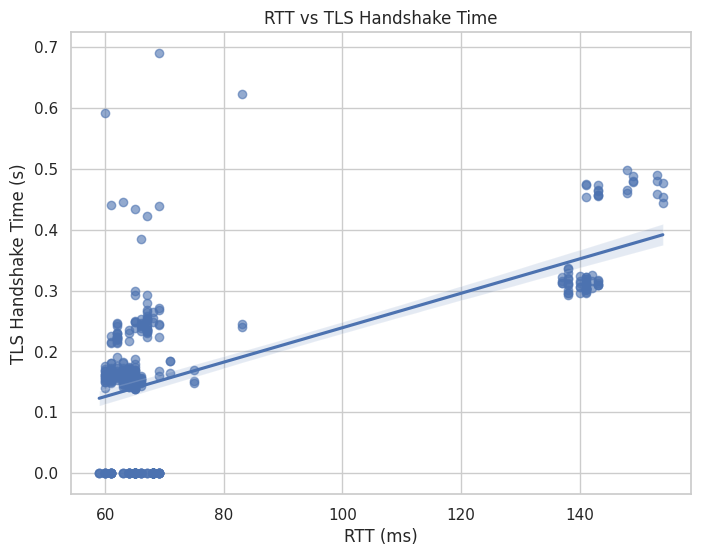

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="rtt_avg_ms",
    y="tls_handshake_time_s",
    scatter_kws={"alpha":0.6}
)

plt.title("RTT vs TLS Handshake Time")
plt.xlabel("RTT (ms)")
plt.ylabel("TLS Handshake Time (s)")

plt.show()

Step 31 — Plot RTT vs Total Download Time

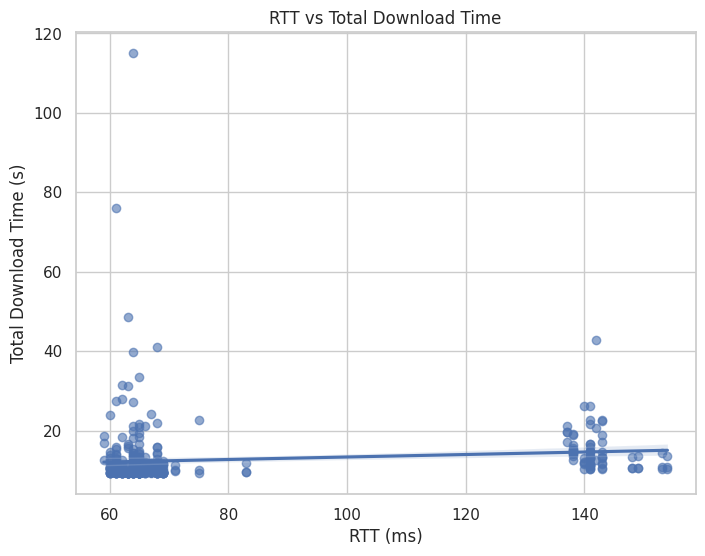

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="rtt_avg_ms",
    y="total_time_s",
    scatter_kws={"alpha":0.6}
)

plt.title("RTT vs Total Download Time")
plt.xlabel("RTT (ms)")
plt.ylabel("Total Download Time (s)")

plt.show()

Step 34 — Plot RTT vs Throughput by Server

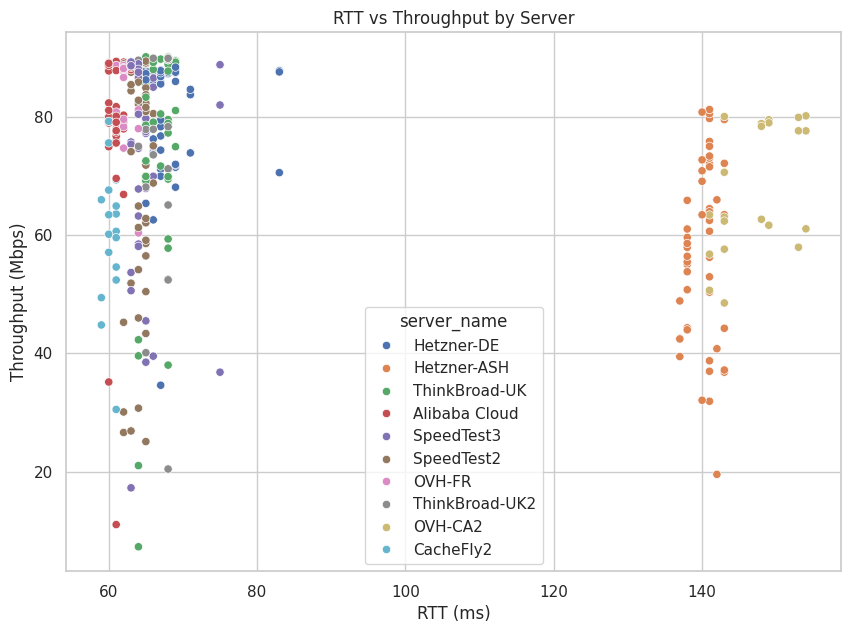

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x="rtt_avg_ms",
    y="throughput_Mbps",
    hue="server_name"
)

plt.title("RTT vs Throughput by Server")
plt.xlabel("RTT (ms)")
plt.ylabel("Throughput (Mbps)")

plt.show()

Step 36 — Plot RTT KDE Distribution

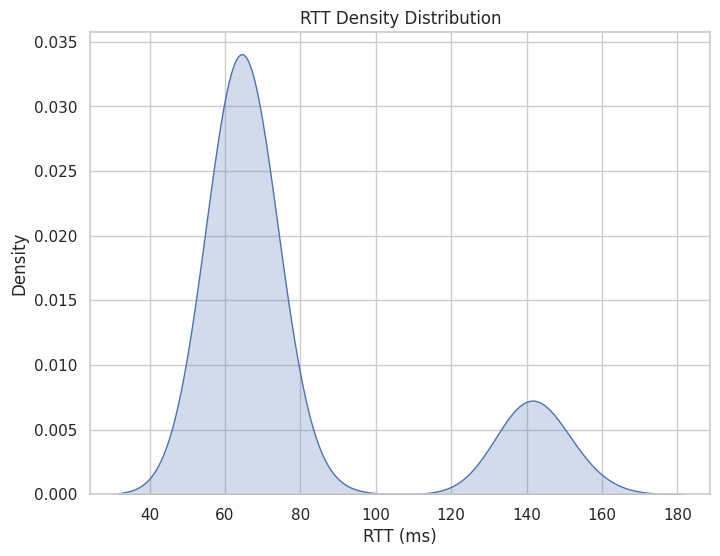

In [ ]:
plt.figure(figsize=(8,6))

sns.kdeplot(df["rtt_avg_ms"], fill=True)

plt.title("RTT Density Distribution")
plt.xlabel("RTT (ms)")

plt.show()

Step 37 — Plot TTFB Distribution per Server

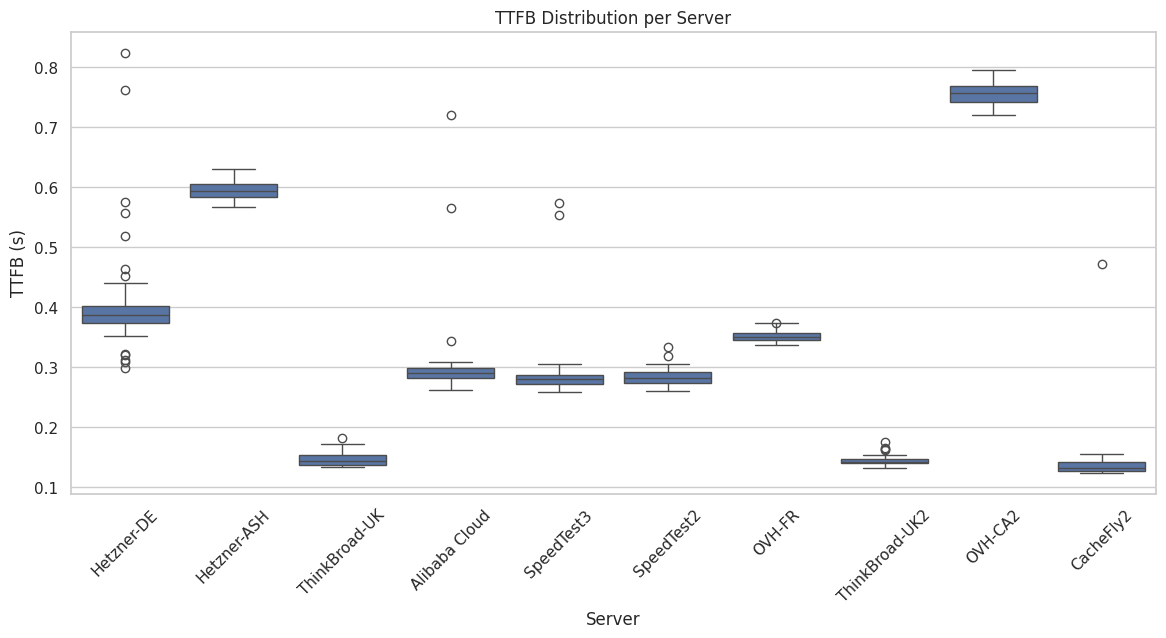

In [ ]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="server_name",
    y="ttfb_s"
)

plt.xticks(rotation=45)

plt.title("TTFB Distribution per Server")
plt.xlabel("Server")
plt.ylabel("TTFB (s)")

plt.show()

In [ ]:
from scipy.stats import pearsonr

pearsonr(df["rtt_avg_ms"], df["tcp_connect_time_s"])

PearsonRResult(statistic=np.float64(0.9508422353355734), pvalue=np.float64(9.666533434476337e-206))

In [ ]:
pearsonr(df["rtt_avg_ms"], df["ttfb_s"])

PearsonRResult(statistic=np.float64(0.8247151764831364), pvalue=np.float64(4.695783426387161e-101))

In [ ]:
pearsonr(df["rtt_avg_ms"], df["total_time_s"])

PearsonRResult(statistic=np.float64(0.121246288427674), pvalue=np.float64(0.014999521590241417))

In [ ]:
df.shape

(402, 9)

اضافي

In [ ]:
import pandas as pd

df = pd.read_csv("phase1_results (1).csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (978, 34)

Columns:
['timestamp_utc', 'server_name', 'url', 'trial', 'host', 'resolved_ip', 'ping_sent', 'ping_received', 'ping_loss_pct', 'rtt_min_ms', 'rtt_avg_ms', 'rtt_max_ms', 'dns_time_s', 'tcp_connect_time_s', 'tls_handshake_time_s', 'ttfb_s', 'total_time_s', 'download_speed_Bps', 'throughput_Mbps', 'http_code', 'remote_ip', 'size_download_bytes', 'ping_status', 'curl_status', 'error_message', 'python_version', 'curl_version', 'platform', 'ip_city', 'ip_region', 'ip_country', 'ip_org', 'ip_timezone', 'ip_loc']


In [ ]:
df["server_name"].value_counts()

,count
server_name,
ThinkBroad-UK,108
OVH-FR,75
Hetzner-ASH,54
Hetzner-DE,54
SpeedTest,54
Debian1,54
Debian2,54
Cloudflare-AC,54
OVH-CA,54


In [ ]:
df_clean = df[
    (df["curl_status"] == "ok") &
    (df["ping_status"] == "ok") &
    (df["size_download_bytes"] == 104857600)
]

df_clean["server_name"].value_counts()

,count
server_name,
Hetzner-DE,54
ThinkBroad-UK,54
SpeedTest2,54
SpeedTest3,54
Alibaba Cloud,53
Hetzner-ASH,52
OVH-FR,21
ThinkBroad-UK2,21
OVH-CA2,21


In [ ]:
print("Valid observations:", len(df_clean))
print("Unique servers:", df_clean["server_name"].nunique())

Valid observations: 402
Unique servers: 10


In [ ]:
[col for col in df.columns if "trial" in col.lower() or "run" in col.lower()]

['trial']

In [ ]:
df_clean.groupby("server_name")["trial"].nunique()

,trial
server_name,
Alibaba Cloud,3
CacheFly2,3
Hetzner-ASH,3
Hetzner-DE,3
OVH-CA2,3
OVH-FR,3
SpeedTest2,3
SpeedTest3,3
ThinkBroad-UK,3
